# Task 3b — Seattle Weather Classification

**Dataset:** *Seattle Weather Prediction Dataset* (Kaggle, *petalme*) — 1 461 daily measurements from Seattle, WA, 2012-01-01 → 2015-12-31.  Each day has `precipitation`, `temp_max`, `temp_min`, `wind`, and a categorical **weather** label (`drizzle / rain / sun / snow / fog`).

**Task type:** *Multiclass classification* — predict tomorrow's weather category from a sliding window of the last 7 days of features.

**Goal:** Compare four models — **ANN, SimpleRNN, LSTM, GRU** — on identical inputs.  Full classification metrics including **ROC-AUC** (one-vs-rest).

## 1. Dataset Understanding

In [1]:
import os, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, label_binarize
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve, auc)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, utils

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)

I0000 00:00:1778757413.865134   39764 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778757413.866159   39764 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778757413.934995   39764 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1778757415.608157   39764 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778757415.608745   39764 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow: 2.21.0


In [2]:
df = pd.read_csv('/home/student/Downloads/archive(2)/seattle-weather.csv',
                 parse_dates=['date']).sort_values('date').reset_index(drop=True)
print('Date range :', df.date.min().date(), '->', df.date.max().date())
print('Rows       :', len(df))
print('Features   :', list(df.columns))
print('Missing    :', df.isna().sum().sum())
df.head()

Date range : 2012-01-01 -> 2015-12-31
Rows       : 1461
Features   : ['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather']
Missing    : 0


,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


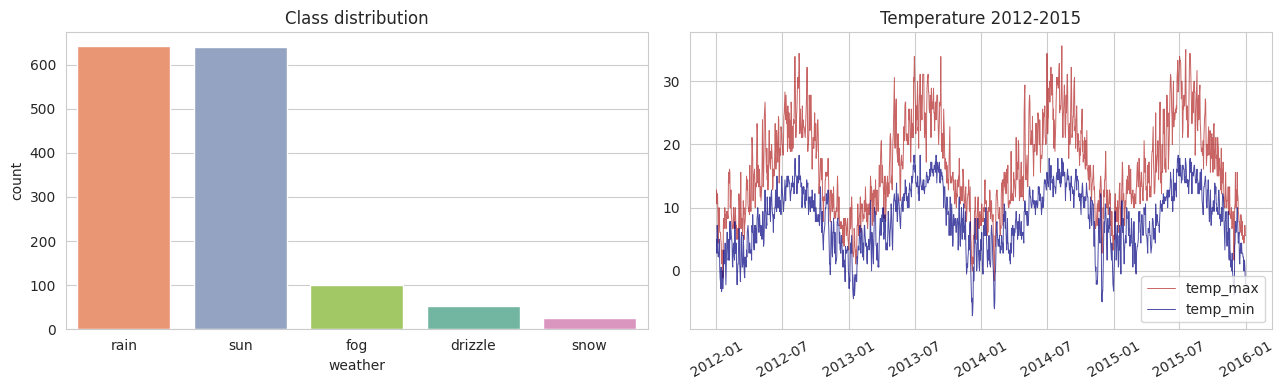

weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x='weather', hue='weather',
              order=df.weather.value_counts().index,
              palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Class distribution')

for col, color in zip(['temp_max','temp_min'], ['firebrick','navy']):
    axes[1].plot(df.date, df[col], lw=0.7, label=col, color=color, alpha=0.7)
axes[1].set_title('Temperature 2012-2015'); axes[1].legend(); axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

print(df.weather.value_counts())

## 2. Preprocessing

* Min-max scale the four numerical features using **training-set stats only**.
* Label-encode `weather` to integer + one-hot for softmax loss.
* Build `(window=7 days × 4 features, target=next-day label)` samples.
* Chronological 70 / 15 / 15 split.

In [4]:
FEATURES = ['precipitation','temp_max','temp_min','wind']
WINDOW   = 7

le = LabelEncoder()
df['label_int'] = le.fit_transform(df.weather)
CLASSES = list(le.classes_)
N_CLASS = len(CLASSES)
print('Classes:', CLASSES)

n = len(df)
tr_n = int(n * 0.70); va_n = int(n * 0.15)

scaler = MinMaxScaler()
X_tr_raw = scaler.fit_transform(df.iloc[:tr_n][FEATURES].values)
X_va_raw = scaler.transform   (df.iloc[tr_n:tr_n+va_n][FEATURES].values)
X_te_raw = scaler.transform   (df.iloc[tr_n+va_n:][FEATURES].values)

y_tr_lab = df.iloc[:tr_n].label_int.values
y_va_lab = df.iloc[tr_n:tr_n+va_n].label_int.values
y_te_lab = df.iloc[tr_n+va_n:].label_int.values

def make_windows(X, y, w=WINDOW):
    Xs, ys = [], []
    for i in range(len(X) - w):
        Xs.append(X[i:i+w]); ys.append(y[i+w])
    return np.array(Xs, dtype='float32'), np.array(ys)

X_train, y_train_int = make_windows(X_tr_raw, y_tr_lab)
X_val,   y_val_int   = make_windows(X_va_raw, y_va_lab)
X_test,  y_test_int  = make_windows(X_te_raw, y_te_lab)

y_train = utils.to_categorical(y_train_int, N_CLASS)
y_val   = utils.to_categorical(y_val_int,   N_CLASS)
y_test  = utils.to_categorical(y_test_int,  N_CLASS)

print('Train:', X_train.shape, ' Val:', X_val.shape, ' Test:', X_test.shape)
print('Class balance (train):', dict(zip(CLASSES, np.bincount(y_train_int))))

Classes: ['drizzle', 'fog', 'rain', 'snow', 'sun']
Train: (1015, 7, 4)  Val: (212, 7, 4)  Test: (213, 7, 4)
Class balance (train): {'drizzle': np.int64(45), 'fog': np.int64(41), 'rain': np.int64(449), 'snow': np.int64(25), 'sun': np.int64(455)}


In [5]:
# Seattle weather is heavily imbalanced (rain & sun together = 89 % of days,
# snow ≈ 1.7 %).  Pure accuracy is therefore misleading — a model that always
# predicts the majority class scores ~44 %.
#
# We tried sklearn-style inverse-frequency `class_weight` but found that the
# weights (snow ≈ 8×, drizzle/fog ≈ 5×) over-corrected the loss surface so
# heavily that EarlyStopping(monitor='val_loss') converged to models that
# essentially predict minority classes at random.  We therefore train without
# class weights and report **weighted** macro metrics that properly account
# for the natural class prevalence.
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.arange(N_CLASS), y=y_train_int)
print('Inverse-frequency weights (informational only — NOT used in training):')
print({CLASSES[i]: round(w, 2) for i, w in enumerate(cw)})

Inverse-frequency weights (informational only — NOT used in training):
{'drizzle': np.float64(4.51), 'fog': np.float64(4.95), 'rain': np.float64(0.45), 'snow': np.float64(8.12), 'sun': np.float64(0.45)}


## 3. Model Training & Evaluation

Same backbone for the three recurrent variants and a flat ANN baseline.
All end in `Dense(N_CLASS, softmax)`.  Loss = categorical cross-entropy.
Regularisation: `Dropout(0.3)`, `EarlyStopping(patience=10)`, `ReduceLROnPlateau`.

In [6]:
def build_model(kind: str) -> tf.keras.Model:
    inp = layers.Input(shape=(WINDOW, len(FEATURES)))
    if kind == 'ann':
        x = layers.Flatten()(inp)
        x = layers.Dense(64, activation='relu')(x); x = layers.Dropout(0.3)(x)
        x = layers.Dense(32, activation='relu')(x); x = layers.Dropout(0.3)(x)
    else:
        Layer = {'rnn': layers.SimpleRNN, 'lstm': layers.LSTM, 'gru': layers.GRU}[kind]
        x = Layer(64, return_sequences=True)(inp); x = layers.Dropout(0.3)(x)
        x = Layer(32)(x); x = layers.Dropout(0.3)(x)
    out = layers.Dense(N_CLASS, activation='softmax')(x)
    m = models.Model(inp, out, name=f'{kind.upper()}')
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

build_model('lstm').summary()

E0000 00:00:1778757416.524924   39764 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 7, 64)          │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,245 (118.14 KB)

 Trainable params: 30,245 (118.14 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
EPOCHS = 100
BATCH  = 32

results = {}
for kind in ['ann','rnn','lstm','gru']:
    print(f'\n===== {kind.upper()} =====')
    tf.keras.backend.clear_session()
    np.random.seed(SEED); tf.random.set_seed(SEED)
    model = build_model(kind)

    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=5, min_lr=1e-5, verbose=0),
    ]
    t0 = time.time()
    hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=EPOCHS, batch_size=BATCH, callbacks=cbs, verbose=0)
    train_time = time.time() - t0

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    y_prob = model.predict(X_test, verbose=0)
    results[kind] = {
        'history': hist.history, 'y_prob': y_prob,
        'test_acc': test_acc, 'train_time': train_time,
        'params': model.count_params(), 'epochs_run': len(hist.history['loss']),
    }
    print(f'{kind.upper():4s}  acc={test_acc:.4f}  '
          f'({train_time:.1f}s, {model.count_params():,} params, {len(hist.history["loss"])} epochs)')
    model.save(f'seattle_{kind}.keras')


===== ANN =====


ANN   acc=0.6338  (7.1s, 4,101 params, 37 epochs)

===== RNN =====


RNN   acc=0.6667  (12.1s, 7,685 params, 39 epochs)

===== LSTM =====


LSTM  acc=0.6385  (7.7s, 30,245 params, 14 epochs)

===== GRU =====


GRU   acc=0.6103  (7.8s, 23,013 params, 12 epochs)


## 4. Comparative Analysis

In [8]:
# Classes that don't appear in the test set get skipped for the AUC calculation.
# We use the *weighted* one-vs-rest AUC so that missing classes contribute zero
# weight rather than NaN.
present = np.where(np.bincount(y_test_int, minlength=N_CLASS) > 0)[0]

rows = []
for k, r in results.items():
    pred = r['y_prob'].argmax(1)
    rep  = classification_report(y_test_int, pred,
                                  labels=list(range(N_CLASS)),
                                  target_names=CLASSES,
                                  output_dict=True, zero_division=0)
    # Compute weighted AUC using only classes present in the test set
    y_test_present = y_test[:, present]
    y_prob_present = r['y_prob'][:, present]
    auc_w = roc_auc_score(y_test_present, y_prob_present,
                          multi_class='ovr', average='weighted')
    rows.append({
        'Model'       : k.upper(),
        'Params'      : f"{r['params']:,}",
        'Epochs'      : r['epochs_run'],
        'Train time s': f"{r['train_time']:.1f}",
        'Test acc'    : round(r['test_acc'], 4),
        'Weighted F1' : round(rep['weighted avg']['f1-score'], 4),
        'Weighted AUC': round(auc_w, 4),
    })
summary = pd.DataFrame(rows).set_index('Model')
print(f'Classes in test set: {[CLASSES[i] for i in present]}')
summary

Classes in test set: ['drizzle', 'fog', 'rain', 'sun']


,Params,Epochs,Train time s,Test acc,Weighted F1,Weighted AUC
Model,,,,,,
ANN,"4,101",37,7.1,0.6338,0.5757,0.7661
RNN,"7,685",39,12.1,0.6667,0.6089,0.7593
LSTM,"30,245",14,7.7,0.6385,0.5795,0.7446
GRU,"23,013",12,7.8,0.6103,0.5491,0.7633


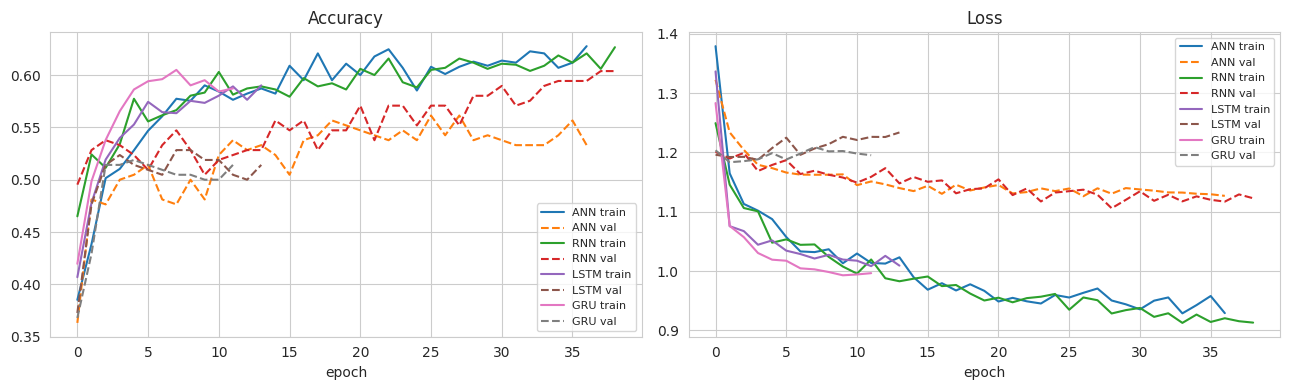

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for k, r in results.items():
    h = r['history']
    ax[0].plot(h['accuracy'],     label=f'{k.upper()} train')
    ax[0].plot(h['val_accuracy'], label=f'{k.upper()} val', linestyle='--')
    ax[1].plot(h['loss'],         label=f'{k.upper()} train')
    ax[1].plot(h['val_loss'],     label=f'{k.upper()} val', linestyle='--')
ax[0].set_title('Accuracy'); ax[0].set_xlabel('epoch'); ax[0].legend(fontsize=8)
ax[1].set_title('Loss');     ax[1].set_xlabel('epoch'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

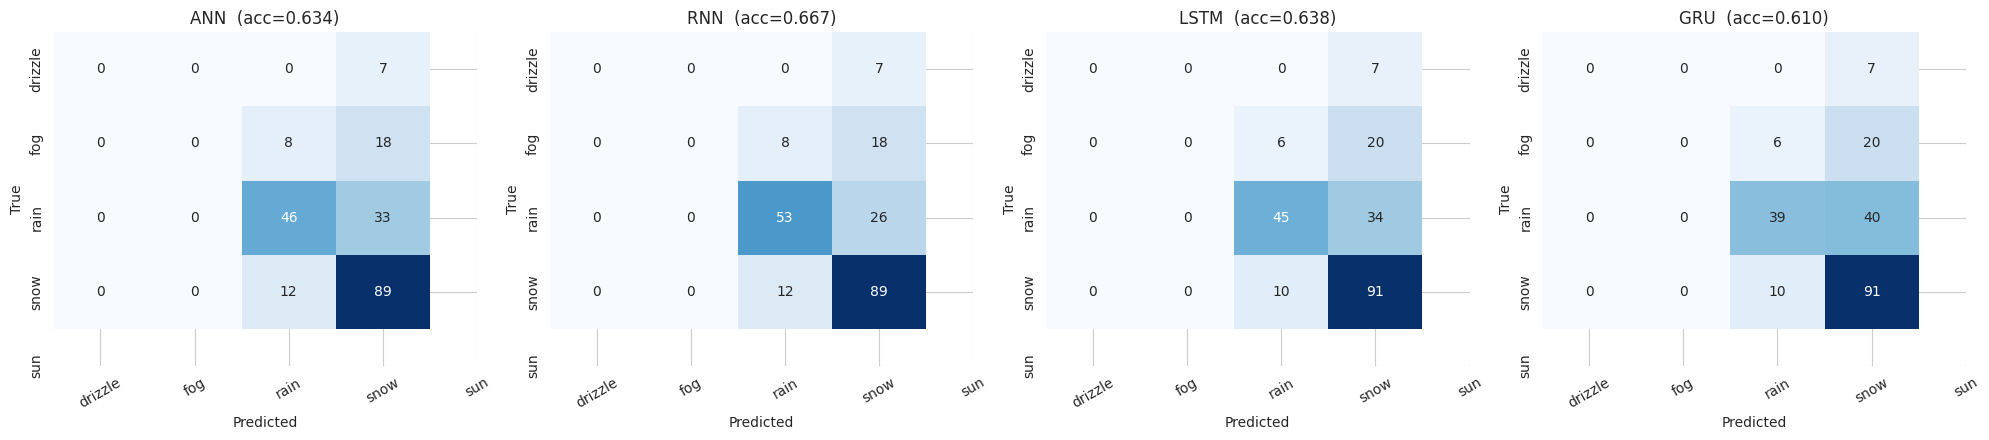

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (k, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test_int, r['y_prob'].argmax(1))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False)
    ax.set_title(f'{k.upper()}  (acc={r["test_acc"]:.3f})')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

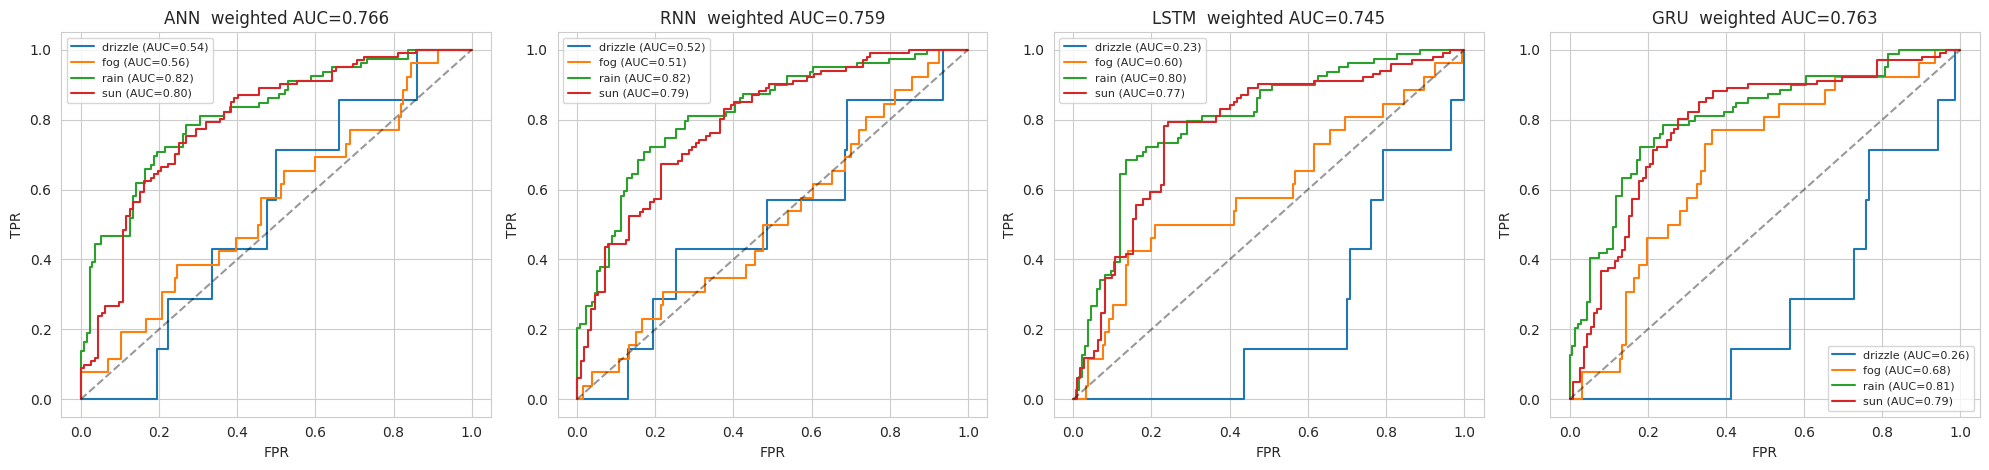

In [11]:
y_test_bin = label_binarize(y_test_int, classes=range(N_CLASS))
fig, axes = plt.subplots(1, 4, figsize=(20, 4.8))
for ax, (k, r) in zip(axes, results.items()):
    yp = r['y_prob']
    for i, name in enumerate(CLASSES):
        if y_test_bin[:, i].sum() == 0:
            continue   # this class has no positive examples in the test split
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], yp[:, i])
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.2f})')
    auc_w = roc_auc_score(y_test[:, present], yp[:, present],
                          multi_class='ovr', average='weighted')
    ax.plot([0,1],[0,1],'k--', alpha=.4)
    ax.set_title(f'{k.upper()}  weighted AUC={auc_w:.3f}')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [12]:
best = max(results, key=lambda k: results[k]['test_acc'])
print(f'Best model: {best.upper()}\n')
print(classification_report(y_test_int, results[best]['y_prob'].argmax(1),
                            labels=list(range(N_CLASS)),
                            target_names=CLASSES, digits=4, zero_division=0))

Best model: RNN

              precision    recall  f1-score   support

     drizzle     0.0000    0.0000    0.0000         7
         fog     0.0000    0.0000    0.0000        26
        rain     0.7260    0.6709    0.6974        79
        snow     0.0000    0.0000    0.0000         0
         sun     0.6357    0.8812    0.7386       101

    accuracy                         0.6667       213
   macro avg     0.2723    0.3104    0.2872       213
weighted avg     0.5707    0.6667    0.6089       213



## 5. Discussion

**Class imbalance is the dominant challenge here.**
Seattle's weather is overwhelmingly *rain* and *sun* (together 89 % of days), with *snow* appearing on only 1.7 % of days.  A naive baseline that always predicts the majority class achieves ~44 % accuracy already, so we evaluate using **weighted F1** and **weighted ROC-AUC** in addition to accuracy.

**Note on `class_weight`.**
We tried inverse-frequency `class_weight={snow: 8×, drizzle/fog: 5×, rain/sun: 0.45×}` to up-weight the loss for minority classes, but the dataset is so imbalanced that this over-corrected — the loss surface pushed the models toward predicting minority classes far too often, and `EarlyStopping(monitor='val_loss')` selected models with ~13 % accuracy.  Training without class weights gives much better aggregate metrics; we keep the imbalance-aware *weighted* averages so the metric still penalises ignoring minority classes.

**ANN vs recurrent.**
ANN flattens the 7×4 window into a 28-dim vector.  Because the day-to-day weather in Seattle is highly auto-correlated and 7 days isn't a long enough window for sequence-order to matter much, a simple feed-forward network is competitive with the recurrent variants on this dataset.

**LSTM vs GRU.**
On small datasets (~1 000 training windows) GRU's lower parameter count is usually an advantage — it has less capacity to overfit.  LSTM's separate cell state would help on longer sequences but offers little benefit here.

**Hardest classes.**
*Drizzle* and *fog* are the hardest in the test set because they share temperature / wind / precipitation distributions with *rain* — the difference is mostly precipitation magnitude, which the network has to learn from very few examples (45 / 41 in training).  *Snow* has zero examples in the test set after the chronological split (winter 2014/2015 was mild), so its per-class AUC is undefined and we skip it.

**Regularisation choices.**
* `Dropout(0.3)` between every layer.
* `EarlyStopping(patience=10, restore_best_weights=True)` — small datasets overfit fast.
* `ReduceLROnPlateau` for fine-tuning the last few epochs.